In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

from data.data_preprocessing import load_and_split_data

# Import model functions
from data.models.bayesian_ridge import bayesian_ridge_model, bayesian_ridge_tuned
from data.models.svr_model import svr_model, svr_tuned
from data.models.random_forest import random_forest_model, random_forest_tuned
from data.models.gradient_boosting import gradient_boosting_model, gradient_boosting_tuned
from data.models.mlp_regressor_model import mlp_regressor_model, mlp_regressor_tuned
from data.models.xgboost_model import xgboost_model, xgboost_tuned
from data.models.stacking_model import stacking_model

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# Load and split data once
X_train, X_test, y_train, y_test, data = load_and_split_data()

In [16]:
# Check the data
print(f'Dataset shape: {data.shape}')
data.head()

Dataset shape: (355, 8)


,A,B,C,D,E,F,G,AOR
0,0.2,0.00005,0.4,0.28,4.000000e-07,0.3,0.6,40.250
1,0.3,0.00005,0.4,0.28,4.000000e-07,0.3,0.6,42.305
2,0.4,0.00005,0.4,0.28,4.000000e-07,0.3,0.6,43.680
3,0.5,0.00005,0.4,0.28,4.000000e-07,0.3,0.6,43.605
4,0.6,0.00005,0.4,0.28,4.000000e-07,0.3,0.6,43.215


In [18]:
# Statistical summary
data.describe()

,A,B,C,D,E,F,G,AOR
count,355.000000,355.000000,355.000000,355.000000,3.550000e+02,355.000000,355.000000,355.000000
mean,0.453400,0.000030,0.405707,0.343448,2.197324e-07,0.365915,0.517538,36.687352
std,0.189653,0.000025,0.190959,0.124833,1.405692e-07,0.132315,0.162453,5.985885
min,0.100000,0.000002,0.100000,0.100000,1.000000e-08,0.100000,0.100000,13.065000
25%,0.300000,0.000008,0.300000,0.280000,6.000000e-08,0.300000,0.365000,32.928750
50%,0.500000,0.000010,0.400000,0.300000,2.000000e-07,0.300000,0.600000,37.145000
75%,0.600000,0.000050,0.400000,0.400000,3.000000e-07,0.400000,0.600000,41.661250
max,0.900000,0.000100,0.900000,0.920000,8.000000e-07,0.900000,0.900000,63.670000


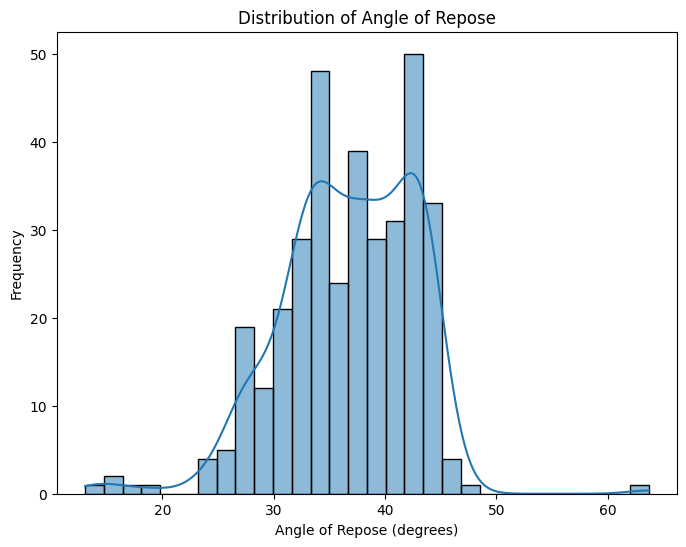

In [21]:
# Distribution of AOR
plt.figure(figsize=(8, 6))
sns.histplot(data['AOR'], kde=True, bins=30)
plt.title('Distribution of Angle of Repose')
plt.xlabel('Angle of Repose (degrees)')
plt.ylabel('Frequency')
plt.show()

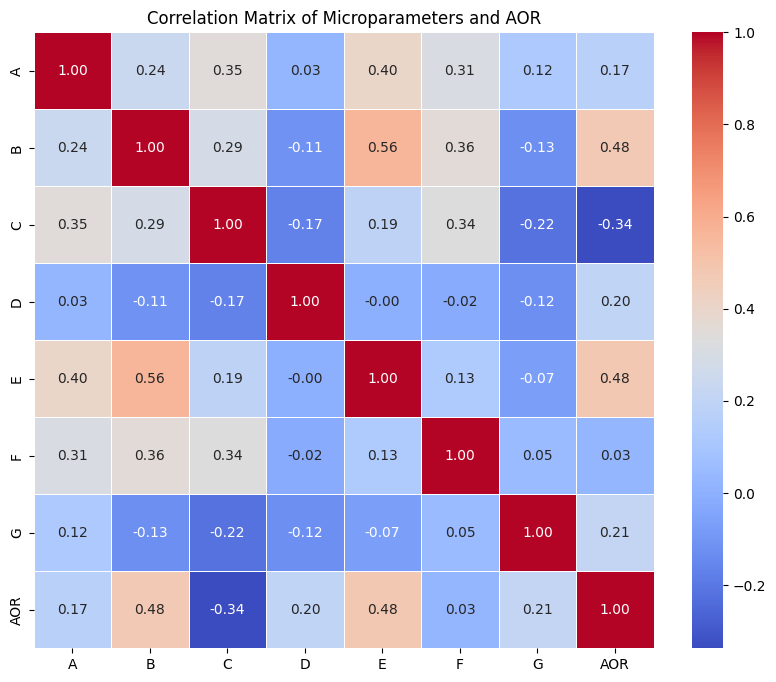

Correlations with AOR:
 AOR    1.000000
E      0.482541
B      0.475126
G      0.212471
D      0.197565
A      0.166894
F      0.025573
C     -0.337008
Name: AOR, dtype: float64


In [27]:
# Compute the correlation matrix
corr_matrix = data.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Microparameters and AOR")
plt.show()

# Focus on AOR correlations
print("Correlations with AOR:\n", corr_matrix["AOR"].sort_values(ascending=False))

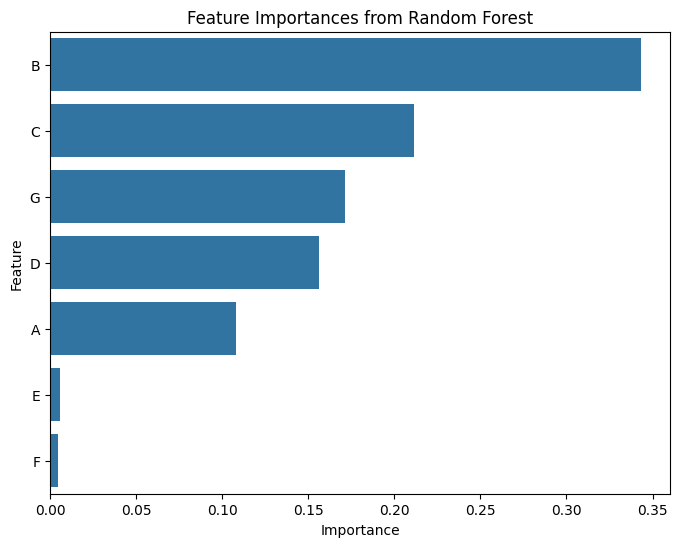

In [26]:
X = data.drop('AOR', axis=1)
y = data['AOR']

# Initialize the model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf.fit(X, y)

# Get feature importances
importances = rf.feature_importances_
feature_names = X.columns
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importances.sort_values(by='Importance', ascending=False, inplace=True)

# Plot feature importances
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importances from Random Forest')
plt.show()

In [31]:


# Dictionary to store results
results = {}

# Bayesian Ridge Regression
_, y_pred, mse, mae, r2 = bayesian_ridge_model(X_train, X_test, y_train, y_test)
results['Bayesian Ridge'] = {'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

_, y_pred, mse, mae, r2 = bayesian_ridge_tuned(X_train, X_test, y_train, y_test)
results['Bayesian Ridge Tuned'] = {'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

# Support Vector Regression
_, y_pred, mse, mae, r2 = svr_model(X_train, X_test, y_train, y_test)
results['SVR'] = {'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

_, y_pred, mse, mae, r2 = svr_tuned(X_train, X_test, y_train, y_test)
results['SVR Tuned'] = {'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

# Random Forest Regression
_, y_pred, mse, mae, r2 = random_forest_model(X_train, X_test, y_train, y_test)
results['Random Forest'] = {'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

_, y_pred, mse, mae, r2 = random_forest_tuned(X_train, X_test, y_train, y_test)
results['Random Forest Tuned'] = {'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

# Gradient Boosting Regression
_, y_pred, mse, mae, r2 = gradient_boosting_model(X_train, X_test, y_train, y_test)
results['Gradient Boosting'] = {'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

_, y_pred, mse, mae, r2 = gradient_boosting_tuned(X_train, X_test, y_train, y_test)
results['Gradient Boosting Tuned'] = {'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

# MLP Regression
_, y_pred, mse, mae, r2 = mlp_regressor_model(X_train, X_test, y_train, y_test)
results['MLP Regression'] = {'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

_, y_pred, mse, mae, r2 = mlp_regressor_tuned(X_train, X_test, y_train, y_test)
results['MLP Regression Tuned'] = {'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

# XGBoost Regression
_, y_pred, mse, mae, r2 = xgboost_model(X_train, X_test, y_train, y_test)
results['XGBoost'] = {'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

_, y_pred, mse, mae, r2 = xgboost_tuned(X_train, X_test, y_train, y_test)
results['XGBoost Tuned'] = {'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

# Stacking Regressor
_, y_pred, mse, mae, r2 = stacking_model(X_train, X_test, y_train, y_test)
results['Stacking Regressor'] = {'MSE': mse, 'MAE': mae, 'R2': r2, 'y_pred': y_pred}

# Convert results to DataFrame
metrics_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})

Bayesian Ridge Regression
MSE: 23.7640
MAE: 4.2034
R2 Score: 0.1564
Best parameters for Bayesian Ridge: {'alpha_1': 1e-06, 'lambda_1': 1e-05, 'n_iter': 300}
Best MSE: 29.5400
MSE: 23.7640
MAE: 4.2034
R2 Score: 0.1564
Support Vector Regression
MSE: 5.1456
MAE: 1.5515
R2 Score: 0.8173
Best parameters for SVR: {'C': 10, 'epsilon': 1, 'kernel': 'rbf'}
Best MSE: 10.6846
MSE: 2.6763
MAE: 1.1906
R2 Score: 0.9050
Random Forest Regression
MSE: 1.5921
MAE: 0.9513
R2 Score: 0.9435
Best parameters for Random Forest: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best MSE: 10.4522
MSE: 1.8424
MAE: 1.0277
R2 Score: 0.9346
Gradient Boosting Regression
MSE: 1.7516
MAE: 0.9313
R2 Score: 0.9378
Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Best MSE: 10.0114
MSE: 2.1680
MAE: 0.9790
R2 Score: 0.9230
MLP Regression


C:\Users\sukap\anaconda3\envs\cv3dst\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MSE: 9.5492
MAE: 2.2724
R2 Score: 0.6610


C:\Users\sukap\anaconda3\envs\cv3dst\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Best parameters for MLP: {'activation': 'tanh', 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.001}
Best MSE: 10.6677


C:\Users\sukap\anaconda3\envs\cv3dst\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MSE: 3.2625
MAE: 1.3562
R2 Score: 0.8842
XGBoost Regression
MSE: 7.5931
MAE: 1.6312
R2 Score: 0.7305
Tuned XGBoost Regression
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
MSE: 1.9538
MAE: 0.9720
R2 Score: 0.9306
Stacking Regressor
MSE: 2.0414
MAE: 1.1023
R2 Score: 0.9275
Percentage Deviation: 2.95%


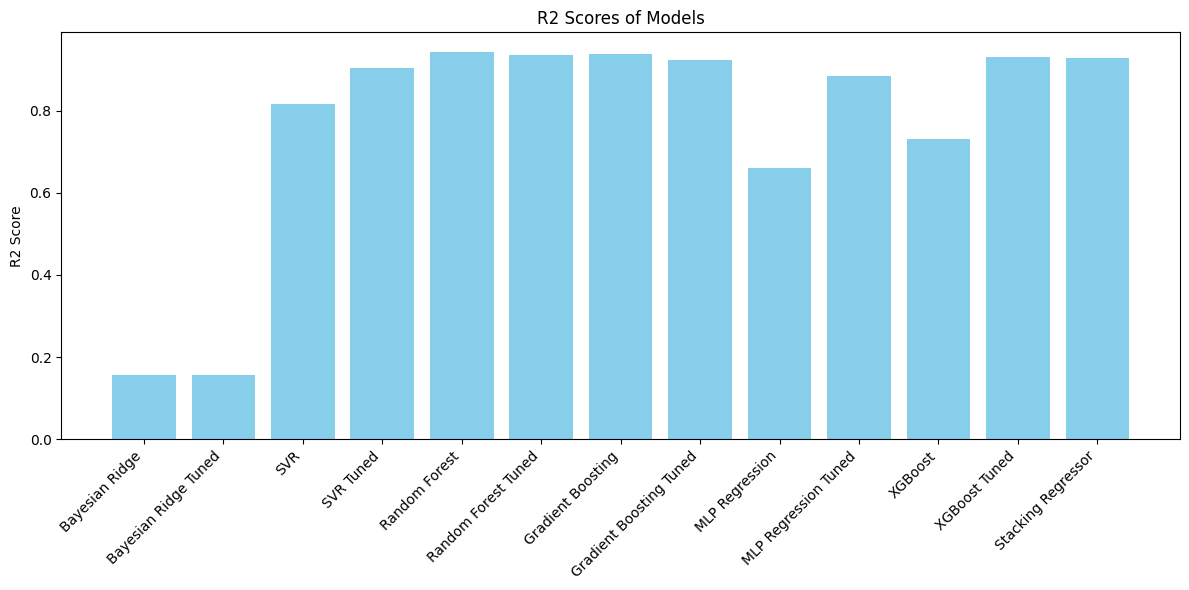

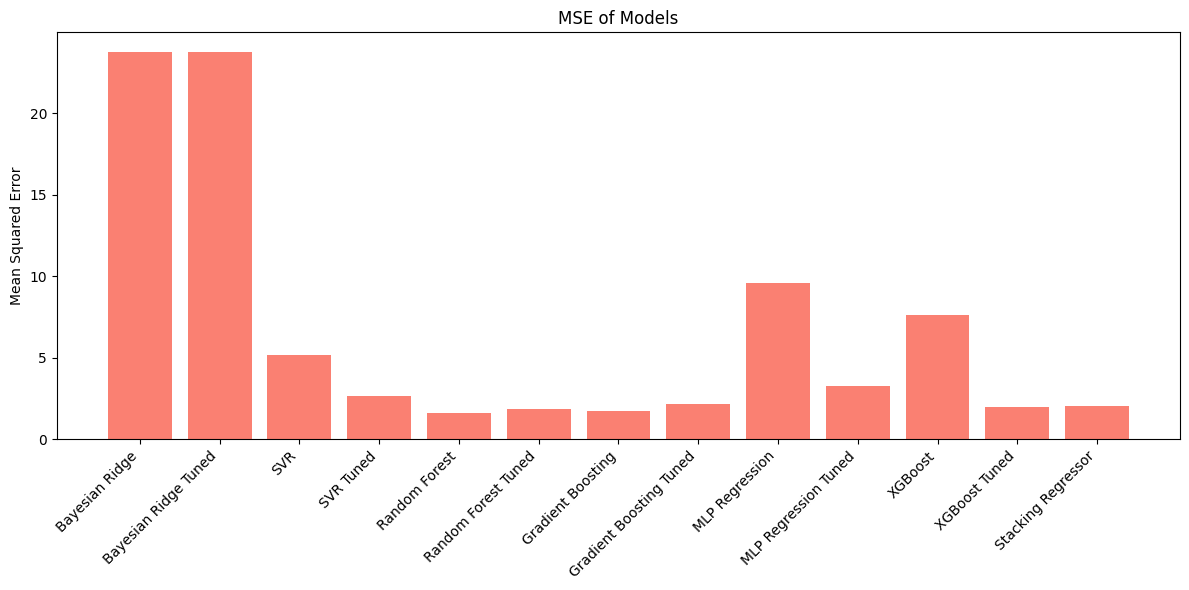

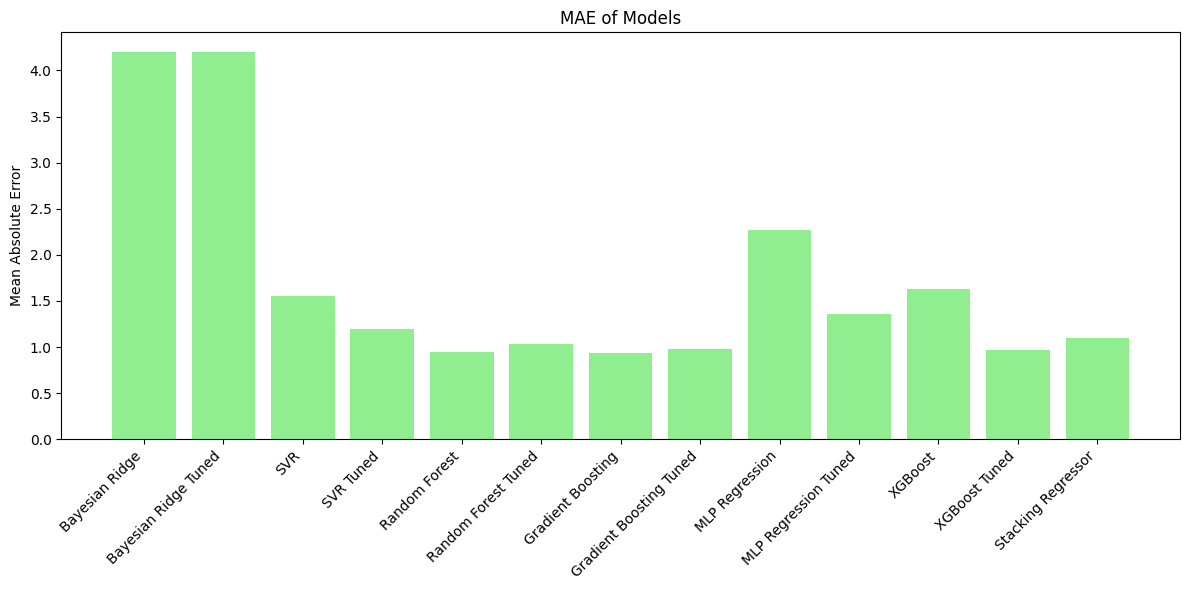

In [32]:
# Plot R2 Scores
plt.figure(figsize=(12, 6))
plt.bar(metrics_df['Model'], metrics_df['R2'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('R2 Score')
plt.title('R2 Scores of Models')
plt.tight_layout()
plt.show()

# Plot MSE Comparison
plt.figure(figsize=(12, 6))
plt.bar(metrics_df['Model'], metrics_df['MSE'], color='salmon')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean Squared Error')
plt.title('MSE of Models')
plt.tight_layout()
plt.show()

# Plot MAE Comparison
plt.figure(figsize=(12, 6))
plt.bar(metrics_df['Model'], metrics_df['MAE'], color='lightgreen')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Mean Absolute Error')
plt.title('MAE of Models')
plt.tight_layout()
plt.show()

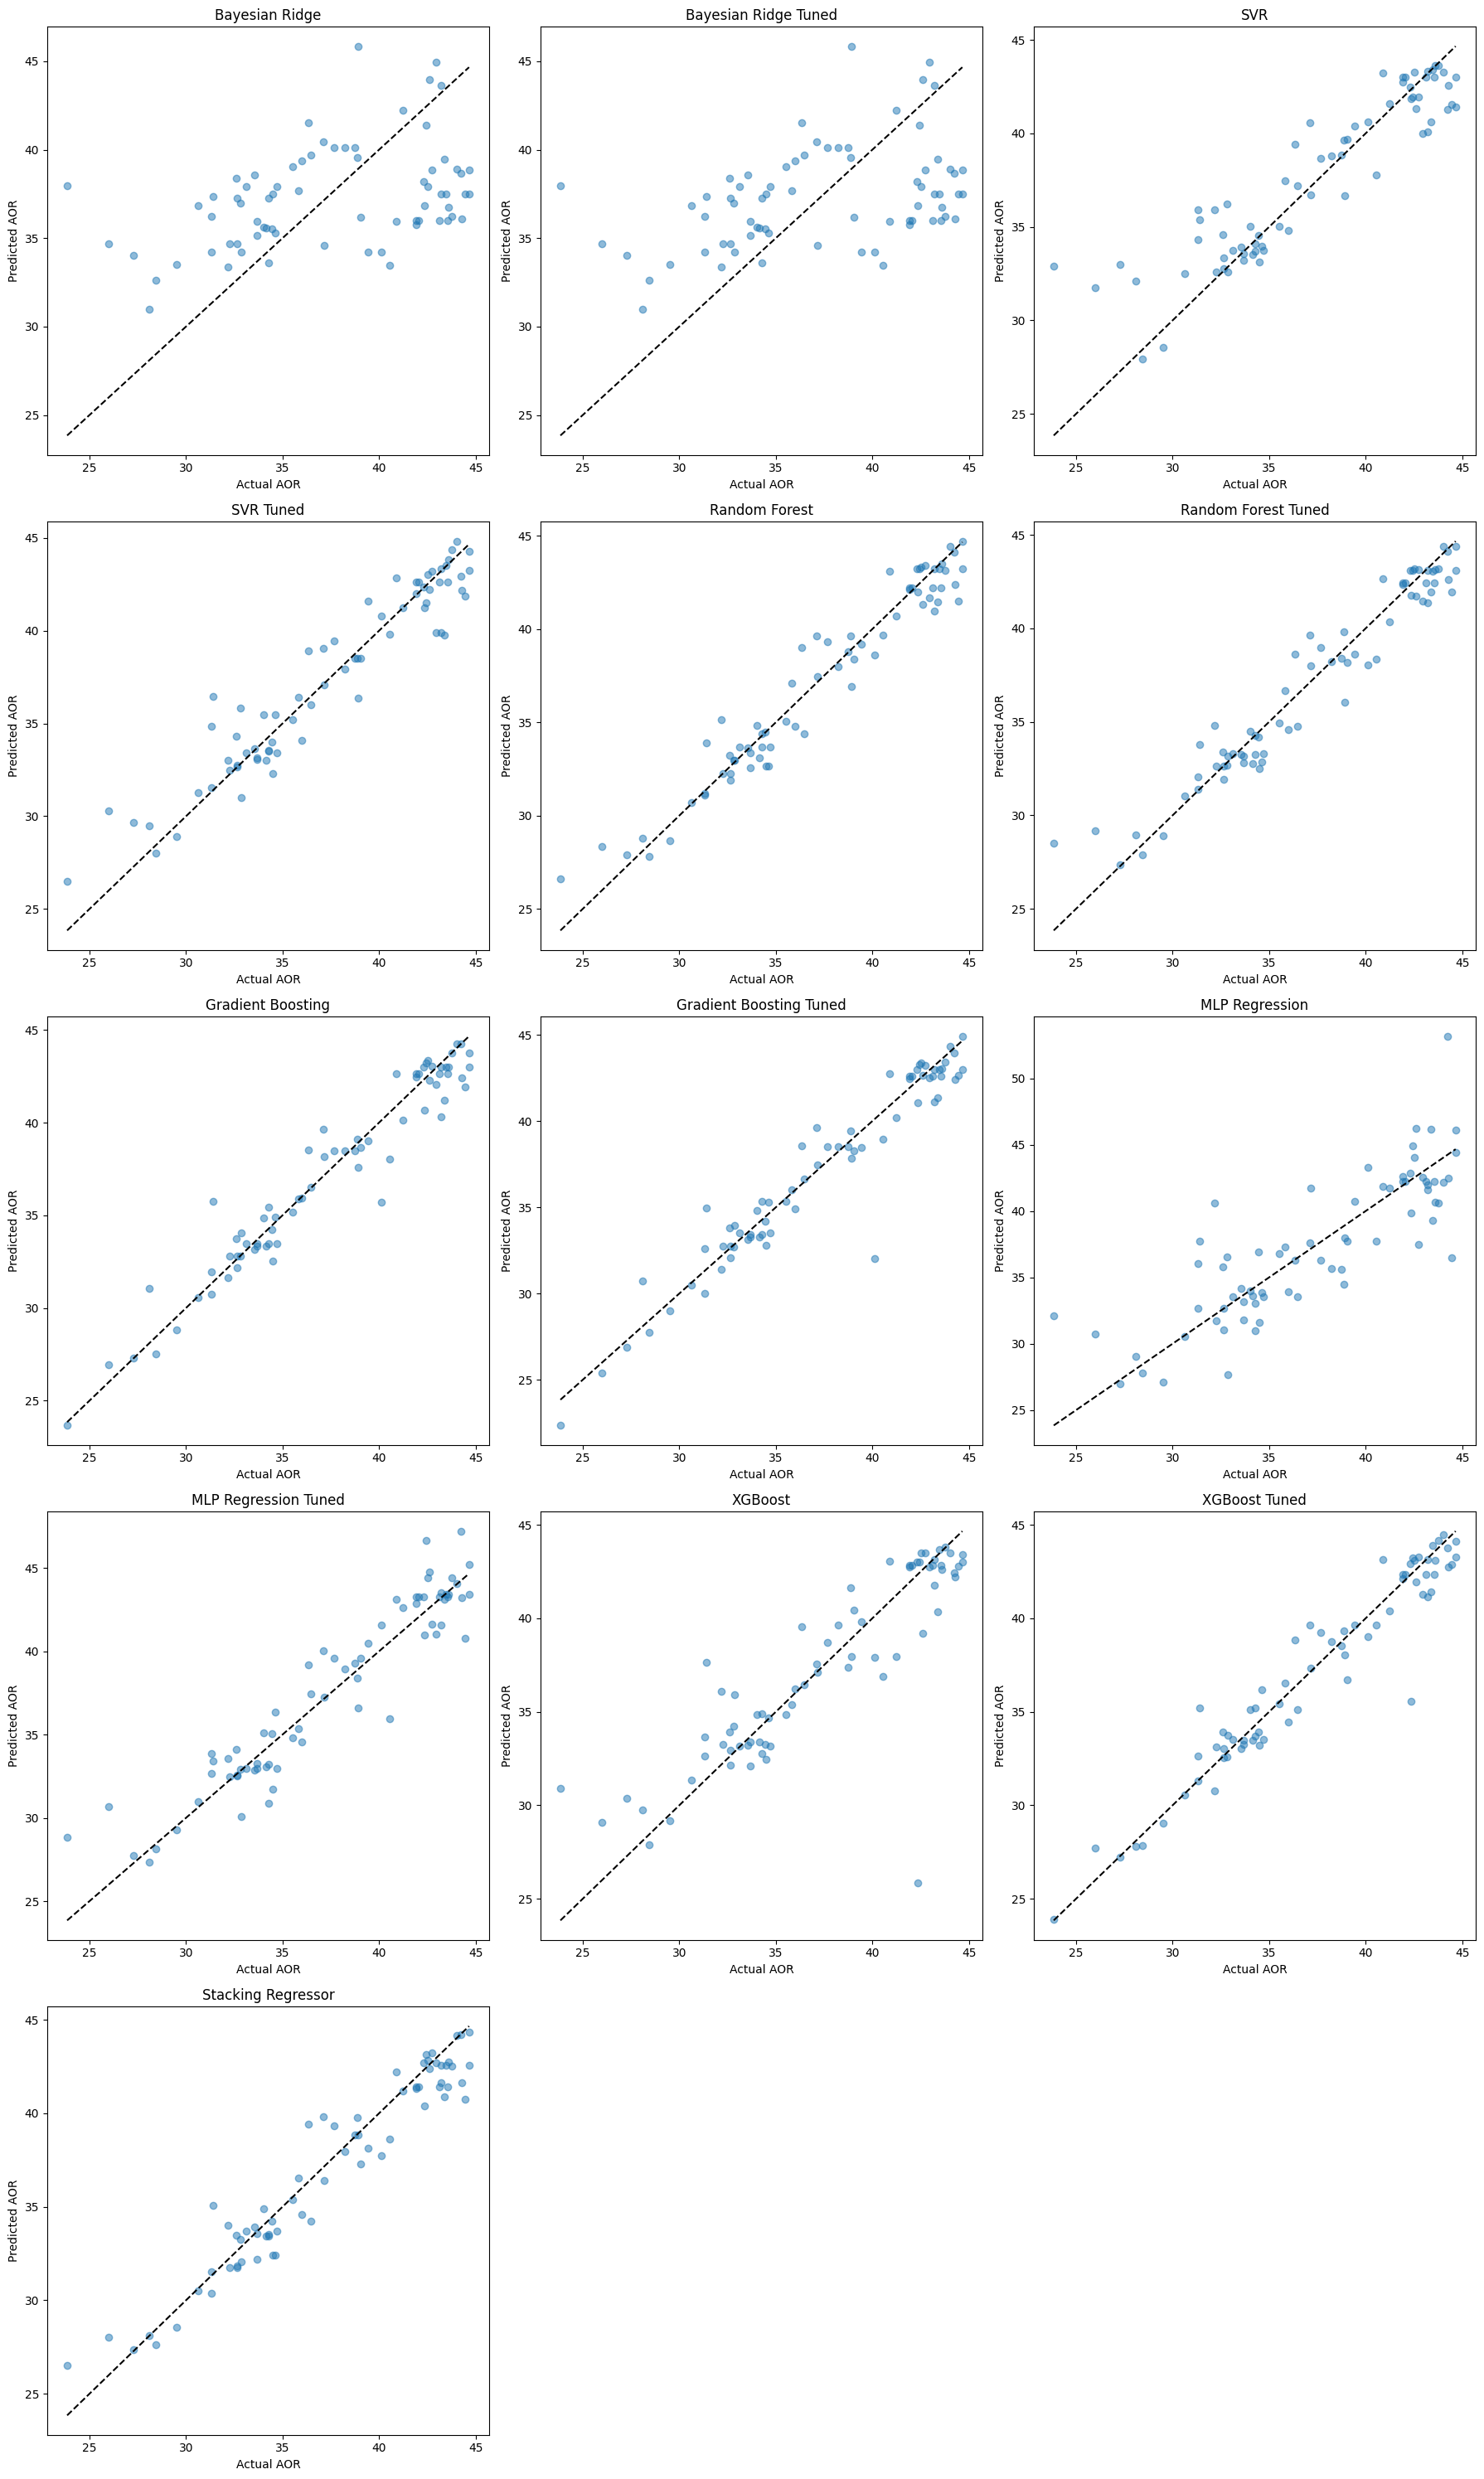

In [33]:
# Plot Actual vs Predicted for Each Model
import numpy as np

models = list(results.keys())
num_models = len(models)
cols = 3
rows = int(np.ceil(num_models / cols))

fig, axes = plt.subplots(rows, cols, figsize=(18, 6 * rows))
axes = axes.flatten()

for idx, model_name in enumerate(models):
    ax = axes[idx]
    y_pred = results[model_name]['y_pred']
    ax.scatter(y_test, y_pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
    ax.set_title(f'{model_name}')
    ax.set_xlabel('Actual AOR')
    ax.set_ylabel('Predicted AOR')

# Remove empty subplots
for idx in range(num_models, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [11]:
# Sort models by R2 Score
best_model = metrics_df.sort_values(by='R2', ascending=False).iloc[0]
print(f"The best model is {best_model['Model']} with an R2 score of {best_model['R2']:.4f}")

The best model is Random Forest with an R2 score of 0.9435


In [14]:
def compute_percentage_error(y_true, y_pred):
    percentage_errors = np.abs((y_true - y_pred) / y_true) * 100
    mean_percentage_error = np.mean(percentage_errors)
    print(f'Mean Percentage Error: {mean_percentage_error:.2f}%')
    return mean_percentage_error

# For the best model (assuming Random Forest performed best)
print('Deviation for Random Forest Regression:')
mean_pct_error_rf = compute_percentage_error(y_test, results['Random Forest Tuned']['y_pred'])

print('Deviation for SVR:')
mean_pct_error_svr = compute_percentage_error(y_test, results['SVR Tuned']['y_pred'])

print('Deviation for Bayesian Ridge Regression:')
mean_pct_error_bayesian = compute_percentage_error(y_test, results['Bayesian Ridge Tuned']['y_pred'])

Deviation for Random Forest Regression:
Mean Percentage Error: 2.89%
Deviation for SVR:
Mean Percentage Error: 3.37%
Deviation for Bayesian Ridge Regression:
Mean Percentage Error: 11.58%
